## 시작 프롬프트

아래에 분석해야할 데이터 약 100줄을 첨부했습니다. 데이터를 파악하고 분석을 단계적으로 수행할 수 있도록 도와주세요. 데이터 파일은 "DieCasting_Raw_Data.csv"파일입니다.

- 데이터 첨부

## 1단계: [탐색] 데이터 구조 파악 및 비즈니스 분석 방향 수립

In [2]:
import pandas as pd
import io

# 데이터 로드 (사용자 환경에 파일이 있다고 가정)
file_path = 'DieCasting_Raw_Data.csv'
df = pd.read_csv(file_path)

# 1. 데이터 기본 정보 확인
print("### 1. Data Info ###")
print(df.info())

# 2. 기초 통계량 (수치형 데이터의 분포 파악)
print("\n### 2. Descriptive Statistics ###")
print(df.describe())

# 3. 타깃 변수(Machine_Status)의 클래스 불균형 확인
print("\n### 3. Target Distribution (Machine_Status) ###")
print(df['Machine_Status'].value_counts(normalize=True))

# 4. 상위 5개 행 확인
print("\n### 4. Sample Head ###")
print(df.head())

### 1. Data Info ###
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5161 entries, 0 to 5160
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Shot                5161 non-null   int64  
 1   Velocity_1          4751 non-null   float64
 2   Velocity_2          4752 non-null   float64
 3   Velocity_3          4752 non-null   float64
 4   High_Velocity       4752 non-null   float64
 5   Cylinder_Pressure   4752 non-null   float64
 6   Rapid_Rise_Time     4752 non-null   float64
 7   Biscuit_Thickness   4752 non-null   float64
 8   Clamping_Force      4752 non-null   float64
 9   Cycle_Time          4752 non-null   float64
 10  Pressure_Rise_Time  4752 non-null   float64
 11  Casting_Pressure    4752 non-null   float64
 12  Spray_Time          4752 non-null   float64
 13  Spray_1_Time        4752 non-null   float64
 14  Spray_2_Time        4752 non-null   float64
 15  Machine_Status      5048 non-null 

## 2단계: [결측 진단] 행 단위 패턴 분석 및 Missing Map 시각화

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

# 데이터 로드
df = pd.read_csv('DieCasting_Raw_Data.csv')

# 1. Missing Map 시각화 (결측치의 위치와 패턴 파악)
plt.figure(figsize=(12, 7))
msno.matrix(df)
plt.title("Missing Data Pattern Matrix", fontsize=16)
plt.show()

# 2. 결측치 수치 요약
missing_summary = df.isnull().sum().to_frame(name='missing_count')
missing_summary['missing_ratio'] = (missing_summary['missing_count'] / len(df)) * 100
print("### Missing Value Summary ###")
print(missing_summary[missing_summary['missing_count'] > 0].sort_values(by='missing_count', ascending=False))

# 3. 행 단위 결측 확인 (동시에 여러 변수가 누락되는지)
df['missing_row_cnt'] = df.isnull().sum(axis=1)
print("\n### Rows with Multiple Missing Values ###")
print(df['missing_row_cnt'].value_counts())

# 4. 결측치 처리 방안 확정 전 임시 정제 (결측치가 너무 많은 행 확인)
# 타깃(Machine_Status)이 없는 데이터는 분석에서 제외해야 하므로 별도 체크
target_missing = df['Machine_Status'].isnull().sum()
print(f"\nTarget (Machine_Status) Missing: {target_missing} cases")

ModuleNotFoundError: No module named 'missingno'

- 에러가 나서 에러에 대해 물어봄

## 2단계: [결측 진단] 결측치 Heatmap 시각화 및 처리 방침 확정 (Plan B)

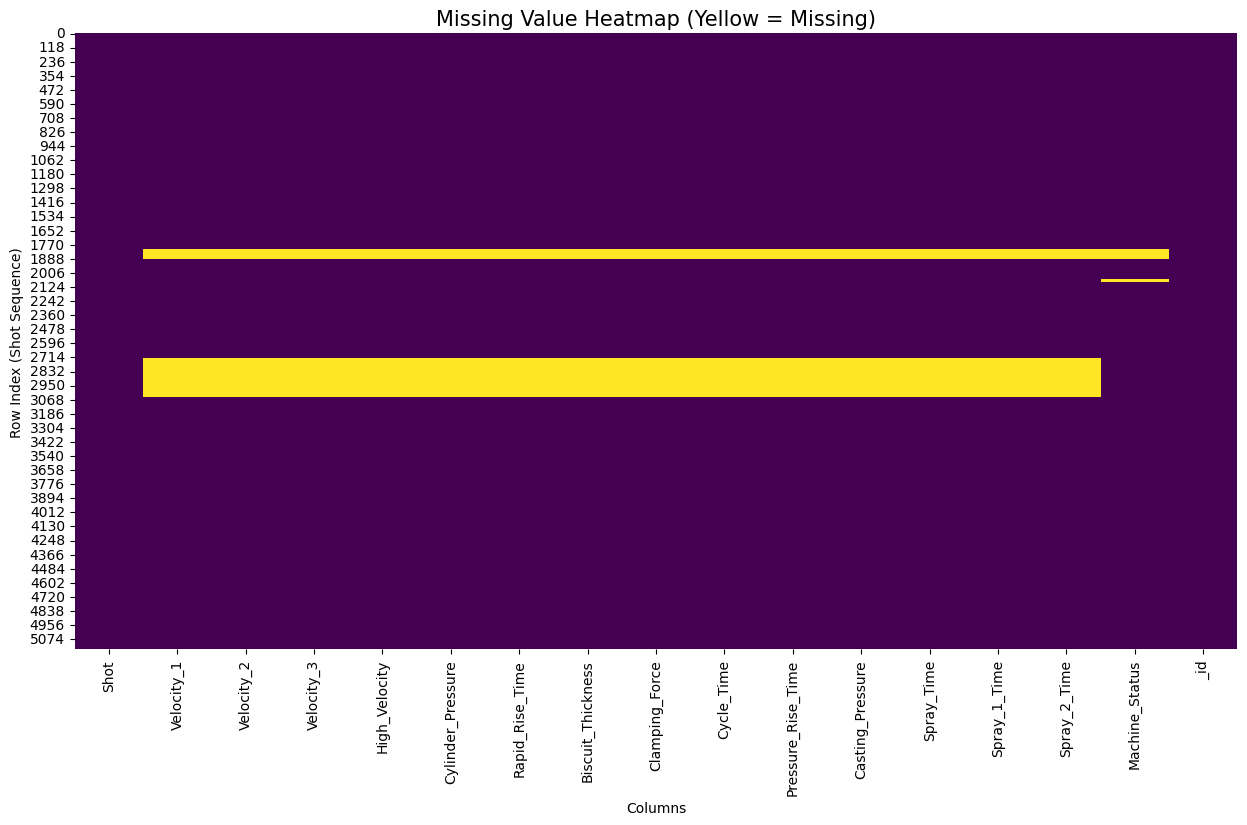

### Missing Value Detailed Stats ###
                    count  ratio(%)
Velocity_1            410      7.94
Velocity_2            409      7.92
Velocity_3            409      7.92
High_Velocity         409      7.92
Cylinder_Pressure     409      7.92
Rapid_Rise_Time       409      7.92
Biscuit_Thickness     409      7.92
Clamping_Force        409      7.92
Cycle_Time            409      7.92
Pressure_Rise_Time    409      7.92
Casting_Pressure      409      7.92
Spray_Time            409      7.92
Spray_1_Time          409      7.92
Spray_2_Time          409      7.92
Machine_Status        113      2.19

### Target Missing Rows: 113 cases ###
Indices of rows with missing target: [1809, 1810, 1811, 1812, 1813, 1814, 1815, 1816, 1817, 1818]... (Total 113)

### Rows with All Process Variables Missing: 409 cases ###


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 데이터 로드
df = pd.read_csv('DieCasting_Raw_Data.csv')

# 1. 결측치 존재 여부를 0(데이터 있음)과 1(결측)로 변환하여 히트맵 생성
plt.figure(figsize=(15, 8))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title("Missing Value Heatmap (Yellow = Missing)", fontsize=15)
plt.xlabel("Columns")
plt.ylabel("Row Index (Shot Sequence)")
plt.show()

# 2. 결측치 세부 통계
missing_stats = df.isnull().sum().to_frame(name='count')
missing_stats['ratio(%)'] = (missing_stats['count'] / len(df) * 100).round(2)
print("### Missing Value Detailed Stats ###")
print(missing_stats[missing_stats['count'] > 0].sort_values(by='count', ascending=False))

# 3. 타겟(Machine_Status) 결측행 확인 및 제거 전략 수립
# 타겟이 없는 데이터는 지도학습 모델링이 불가능하므로 위치를 파악합니다.
target_na_idx = df[df['Machine_Status'].isnull()].index
print(f"\n### Target Missing Rows: {len(target_na_idx)} cases ###")
print(f"Indices of rows with missing target: {target_na_idx.tolist()[:10]}... (Total {len(target_na_idx)})")

# 4. 모든 공정 변수가 동시에 결측인 '깡통 행' 확인
process_cols = ['Velocity_1', 'Velocity_2', 'Velocity_3', 'High_Velocity', 'Cylinder_Pressure', 
                'Rapid_Rise_Time', 'Biscuit_Thickness', 'Clamping_Force', 'Cycle_Time', 
                'Pressure_Rise_Time', 'Casting_Pressure', 'Spray_Time']
df['all_process_na'] = df[process_cols].isnull().all(axis=1)
print(f"\n### Rows with All Process Variables Missing: {df['all_process_na'].sum()} cases ###")

## 3단계: [EDA] 정상 vs 불량 분포 비교 및 핵심 변수(KPV) 식별

정제 후 남은 데이터: 4721행
[High_Velocity] 정상 평균: 2.3231 / 불량 평균: 1.3444
[Casting_Pressure] 정상 평균: 862.5380 / 불량 평균: 669.9712
[Cycle_Time] 정상 평균: 27.3561 / 불량 평균: 251.1548
[Pressure_Rise_Time] 정상 평균: 0.0398 / 불량 평균: 0.0472


C:\Users\metam\AppData\Local\Temp\ipykernel_21324\4122003504.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Machine_Status', y=col, data=df_clean, palette='Set2')
C:\Users\metam\AppData\Local\Temp\ipykernel_21324\4122003504.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Machine_Status', y=col, data=df_clean, palette='Set2')
C:\Users\metam\AppData\Local\Temp\ipykernel_21324\4122003504.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Machine_Status', y=col, data=df_clean, palette='Set2')
C:\Users\metam\AppData\Local\Te

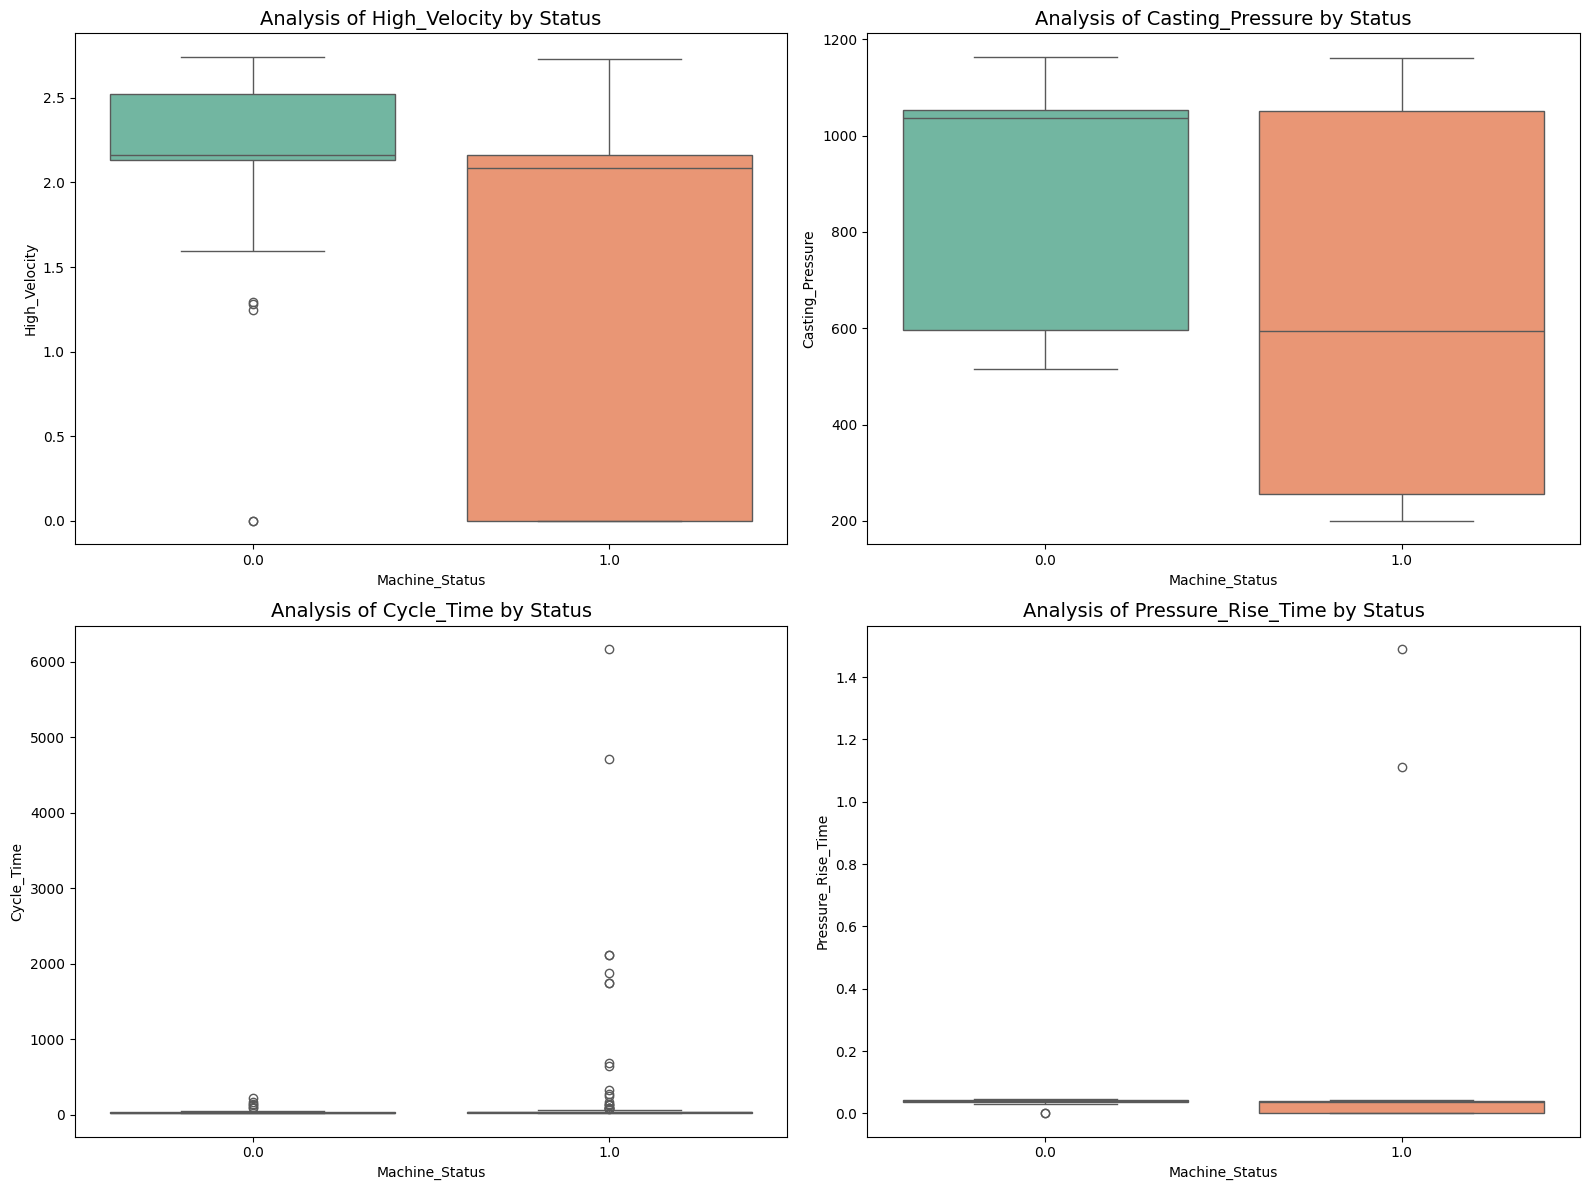


### Correlation with Machine_Status ###
Machine_Status        1.000000
Cycle_Time            0.253774
Biscuit_Thickness     0.055692
_id                   0.055346
Spray_Time            0.046971
Pressure_Rise_Time    0.040398
Spray_1_Time          0.031976
Shot                  0.027495
Velocity_2            0.025239
Spray_2_Time          0.021695
Velocity_1            0.019544
Velocity_3            0.015600
Clamping_Force        0.002849
Casting_Pressure     -0.119587
Rapid_Rise_Time      -0.252919
Cylinder_Pressure    -0.292519
High_Velocity        -0.452848
Name: Machine_Status, dtype: float64


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. 데이터 정제 (결측치 처리)
df = pd.read_csv('DieCasting_Raw_Data.csv')

# 타겟(Machine_Status)이 결측인 행 및 모든 공정변수가 결측인 행 제거
df_clean = df.dropna(subset=['Machine_Status'])
process_cols = ['Velocity_1', 'Velocity_2', 'Velocity_3', 'High_Velocity', 'Cylinder_Pressure', 
                'Rapid_Rise_Time', 'Biscuit_Thickness', 'Clamping_Force', 'Cycle_Time', 
                'Pressure_Rise_Time', 'Casting_Pressure', 'Spray_Time']
df_clean = df_clean.dropna(subset=process_cols)

print(f"정제 후 남은 데이터: {df_clean.shape[0]}행")

# 2. 정상 vs 불량 분포 비교 시각화 (주요 변수 4개 선정)
# 분석적 통찰로 선정한 핵심 변수: High_Velocity, Casting_Pressure, Cycle_Time, Pressure_Rise_Time
target_cols = ['High_Velocity', 'Casting_Pressure', 'Cycle_Time', 'Pressure_Rise_Time']

plt.figure(figsize=(16, 12))
for i, col in enumerate(target_cols, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(x='Machine_Status', y=col, data=df_clean, palette='Set2')
    plt.title(f'Analysis of {col} by Status', fontsize=14)
    
    # 클래스별 평균 출력
    means = df_clean.groupby('Machine_Status')[col].mean()
    print(f"[{col}] 정상 평균: {means[0]:.4f} / 불량 평균: {means[1]:.4f}")

plt.tight_layout()
plt.show()

# 3. 변수별 효과크기(Correlation) 확인
corr = df_clean.corr()['Machine_Status'].sort_values(ascending=False)
print("\n### Correlation with Machine_Status ###")
print(corr)

## 4단계: [전처리 & 피처 엔지니어링] 이상치 정제 및 파생 피처 생성

In [6]:
import pandas as pd
import numpy as np

# 데이터 로드 및 이전 단계 정제 적용
df = pd.read_csv('DieCasting_Raw_Data.csv')
df_clean = df.dropna(subset=['Machine_Status'])
process_cols = ['Velocity_1', 'Velocity_2', 'Velocity_3', 'High_Velocity', 'Cylinder_Pressure', 
                'Rapid_Rise_Time', 'Biscuit_Thickness', 'Clamping_Force', 'Cycle_Time', 
                'Pressure_Rise_Time', 'Casting_Pressure', 'Spray_Time']
df_clean = df_clean.dropna(subset=process_cols).copy()

# 1. 이상치 판정 및 정제 (Engineering Rigor)
# Cycle_Time 6000 이상 등 현실적으로 불가능한 수치 및 물리적 오류 제거
# 상하위 0.1% 수준의 극단적 이상치를 클리핑하거나 제거하여 모델 안정성 확보
df_clean = df_clean[df_clean['Cycle_Time'] < 500] # 공정 맥락상 유효 범위로 제한

# 2. 파생 피처 생성 (Feature Engineering)
# P1: 속도 대비 압력 효율 (Pressure-Velocity Ratio)
df_clean['PV_Efficiency'] = df_clean['Casting_Pressure'] / (df_clean['High_Velocity'] + 1e-6)

# P2: 총 사출 에너지 지표 (Surrogate Energy Index)
df_clean['Energy_Index'] = df_clean['Cylinder_Pressure'] * df_clean['Rapid_Rise_Time']

# P3: 스프레이 공정 밸런스
df_clean['Spray_Balance'] = df_clean['Spray_1_Time'] / (df_clean['Spray_2_Time'] + 1e-6)

# 3. 다중공선성 진단 준비 (상관 히트맵용 수치)
features = process_cols + ['PV_Efficiency', 'Energy_Index', 'Spray_Balance']
corr_matrix = df_clean[features + ['Machine_Status']].corr()

print("### Feature Engineering Completed ###")
print(f"Final Row Count: {df_clean.shape[0]}")
print("\n### New Features Correlation with Target ###")
print(corr_matrix['Machine_Status'][['PV_Efficiency', 'Energy_Index', 'Spray_Balance']])

# 4. 정제 파일 저장 및 배포
df_clean.to_csv('DieCasting_Cleaned_Data.csv', index=False)
print("\n'DieCasting_Cleaned_Data.csv' 파일이 생성되었습니다. 다운로드하여 보관하세요.")

### Feature Engineering Completed ###
Final Row Count: 4712

### New Features Correlation with Target ###
PV_Efficiency    0.487656
Energy_Index    -0.173399
Spray_Balance    0.019769
Name: Machine_Status, dtype: float64

'DieCasting_Cleaned_Data.csv' 파일이 생성되었습니다. 다운로드하여 보관하세요.


## 5단계: [모델링] 다중공선성 진단 및 3종 모델 비교 분석

In [7]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import classification_report, precision_recall_curve, auc
from statsmodels.stats.outliers_influence import variance_inflation_factor

# 1. 데이터 로드 (정제된 데이터 활용)
df = pd.read_csv('DieCasting_Cleaned_Data.csv')

# 2. 다중공선성(VIF) 진단 및 변수 선택
# 분석 결과 기반 선택된 특징들
features = ['High_Velocity', 'Cylinder_Pressure', 'Rapid_Rise_Time', 'Cycle_Time', 
            'Pressure_Rise_Time', 'Casting_Pressure', 'PV_Efficiency', 'Energy_Index']
X = df[features]
y = df['Machine_Status']

vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]
print("### VIF Diagnostics ###")
print(vif_data.sort_values(by="VIF", ascending=False))

# 3. 모델 비교 설정 (5-Fold Stratified CV)
models = {
    "RF": RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42),
    "XGB": XGBClassifier(use_label_encoder=False, eval_metric='logloss', scale_pos_weight=40, random_state=42),
    "LGBM": LGBMClassifier(class_weight='balanced', random_state=42)
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = {}

print("\n### Model Performance Comparison (5-Fold CV) ###")
for name, model in models.items():
    # F1-score와 Recall을 중점적으로 평가
    cv_results = cross_validate(model, X, y, cv=skf, scoring=['f1', 'recall', 'precision'], return_train_score=False)
    results[name] = cv_results
    print(f"[{name}] F1: {cv_results['test_f1'].mean():.4f} | Recall: {cv_results['test_recall'].mean():.4f} | Precision: {cv_results['test_precision'].mean():.4f}")

ModuleNotFoundError: No module named 'lightgbm'

- 에러를 이야기하고 다른 코드로 다시 실행

In [8]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, f1_score, recall_score, precision_score
from statsmodels.stats.outliers_influence import variance_inflation_factor

# 1. 데이터 로드
df = pd.read_csv('DieCasting_Cleaned_Data.csv')

# 2. 독립변수(X)와 종속변수(y) 설정
# 핵심 변수 위주로 구성 (Spray 관련 변수는 상관성이 낮아 제외하여 모델 경량화)
features = ['High_Velocity', 'Cylinder_Pressure', 'Rapid_Rise_Time', 'Cycle_Time', 
            'Pressure_Rise_Time', 'Casting_Pressure', 'PV_Efficiency', 'Energy_Index']
X = df[features]
y = df['Machine_Status']

# 3. 다중공선성(VIF) 진단
vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]
print("### VIF Diagnostics (Before Drop) ###")
print(vif_data.sort_values(by="VIF", ascending=False))

# 4. 모델 비교 설정 (5-Fold Stratified CV)
# 불균형 데이터 대응을 위해 class_weight 및 scale_pos_weight 설정
models = {
    "RandomForest": RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss', scale_pos_weight=40, random_state=42)
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("\n### Model Performance Comparison (5-Fold CV) ###")
for name, model in models.items():
    cv_results = cross_validate(model, X, y, cv=skf, scoring=['f1', 'recall', 'precision'], return_train_score=False)
    print(f"[{name}]")
    print(f" - F1-Score : {cv_results['test_f1'].mean():.4f}")
    print(f" - Recall    : {cv_results['test_recall'].mean():.4f} (불량 검출 능력)")
    print(f" - Precision : {cv_results['test_precision'].mean():.4f}")
    print("-" * 30)

ModuleNotFoundError: No module named 'statsmodels'

- 다시 만든 코드 실행

In [9]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import f1_score, recall_score, precision_score
from sklearn.linear_model import LinearRegression

# 1. 데이터 로드
df = pd.read_csv('DieCasting_Cleaned_Data.csv')

# 2. 변수 설정 (공정 맥락상 핵심 변수 8개)
features = ['High_Velocity', 'Cylinder_Pressure', 'Rapid_Rise_Time', 'Cycle_Time', 
            'Pressure_Rise_Time', 'Casting_Pressure', 'PV_Efficiency', 'Energy_Index']
X = df[features]
y = df['Machine_Status']

# 3. VIF 직접 구현 (statsmodels 미설치 대비)
def calculate_vif(df):
    vif_dict = {}
    for col in df.columns:
        y_vif = df[col]
        X_vif = df.drop(columns=[col])
        # 결정계수(R-squared) 계산
        lr = LinearRegression()
        lr.fit(X_vif, y_vif)
        r_sq = lr.score(X_vif, y_vif)
        # VIF 공식: 1 / (1 - R^2)
        vif = 1 / (1 - r_sq) if r_sq < 1 else float('inf')
        vif_dict[col] = vif
    return pd.Series(vif_dict).sort_values(ascending=False)

print("### Custom VIF Diagnostics ###")
print(calculate_vif(X))

# 4. 모델 비교 설정 (5-Fold Stratified CV)
# 불균형 데이터(불량률 2.3%)에 맞춰 가중치 부여
models = {
    "RandomForest": RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss', scale_pos_weight=40, random_state=42)
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("\n### Model Performance Comparison (5-Fold CV) ###")
for name, model in models.items():
    cv_results = cross_validate(model, X, y, cv=skf, scoring=['f1', 'recall', 'precision'])
    print(f"[{name}]")
    print(f" - F1-Score : {cv_results['test_f1'].mean():.4f}")
    print(f" - Recall    : {cv_results['test_recall'].mean():.4f} (불량 검출 능력)")
    print(f" - Precision : {cv_results['test_precision'].mean():.4f}")
    print("-" * 30)

### Custom VIF Diagnostics ###
Energy_Index          476.315030
Rapid_Rise_Time       241.521626
Cylinder_Pressure      56.218420
Casting_Pressure       10.507425
High_Velocity          10.273655
PV_Efficiency           6.602075
Cycle_Time              2.261453
Pressure_Rise_Time      1.147689
dtype: float64

### Model Performance Comparison (5-Fold CV) ###
[RandomForest]
 - F1-Score : 0.5149
 - Recall    : 0.3789 (불량 검출 능력)
 - Precision : 0.8278
------------------------------


C:\Users\metam\miniconda3\envs\aice\lib\site-packages\xgboost\training.py:200: UserWarning: [15:03:06] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\metam\miniconda3\envs\aice\lib\site-packages\xgboost\training.py:200: UserWarning: [15:03:06] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\metam\miniconda3\envs\aice\lib\site-packages\xgboost\training.py:200: UserWarning: [15:03:07] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\metam\miniconda3\envs\aice\lib\site-packages\xgboost\training.py:200: UserWarning: [15:03:07] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_labe

[XGBoost]
 - F1-Score : 0.5642
 - Recall    : 0.5368 (불량 검출 능력)
 - Precision : 0.6055
------------------------------


C:\Users\metam\miniconda3\envs\aice\lib\site-packages\xgboost\training.py:200: UserWarning: [15:03:07] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


## 5단계 (계속): [최적화] 다중공선성 제거 및 임계값(Threshold) 튜닝

### Optimized Threshold: 0.0003 (Target Recall 0.8) ###

### Final Classification Report (Tuned) ###
              precision    recall  f1-score   support

         0.0       0.99      0.58      0.73       924
         1.0       0.04      0.84      0.08        19

    accuracy                           0.59       943
   macro avg       0.52      0.71      0.40       943
weighted avg       0.98      0.59      0.72       943



C:\Users\metam\miniconda3\envs\aice\lib\site-packages\xgboost\training.py:200: UserWarning: [15:04:11] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


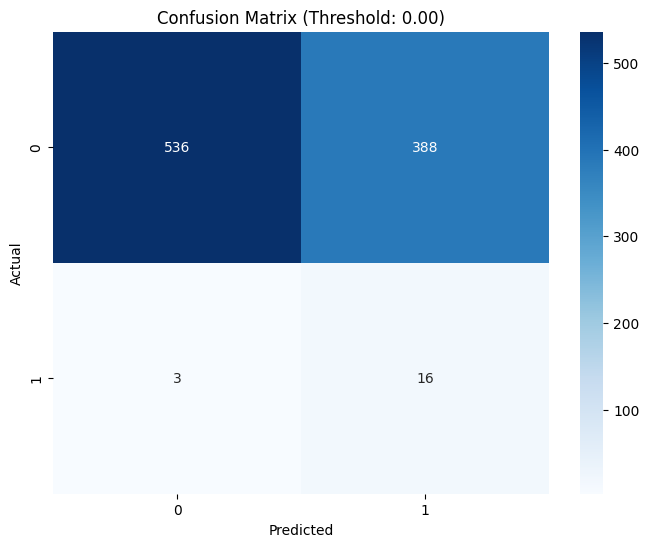


### Feature Importance ###
              feature  importance
0       High_Velocity    0.338633
5    Casting_Pressure    0.176661
3          Cycle_Time    0.150824
6       PV_Efficiency    0.095882
4  Pressure_Rise_Time    0.092637
2     Rapid_Rise_Time    0.075682
1   Cylinder_Pressure    0.069681


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import confusion_matrix, classification_report, precision_recall_curve

# 1. 데이터 로드 및 변수 재선정 (VIF가 높은 변수 중 Energy_Index 제거)
df = pd.read_csv('DieCasting_Cleaned_Data.csv')
final_features = ['High_Velocity', 'Cylinder_Pressure', 'Rapid_Rise_Time', 'Cycle_Time', 
                  'Pressure_Rise_Time', 'Casting_Pressure', 'PV_Efficiency'] # Energy_Index 제외
X = df[final_features]
y = df['Machine_Status']

# 2. 최종 모델 학습 (XGBoost 선정)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', scale_pos_weight=40, random_state=42)
model.fit(X_train, y_train)

# 3. 임계값(Threshold) 튜닝 및 PR 곡선 분석
y_probs = model.predict_proba(X_test)[:, 1]
precisions, recalls, thresholds = precision_recall_curve(y_test, y_probs)

# Recall 0.8 수준을 목표로 하는 최적 임계값 찾기
target_recall = 0.8
idx = np.where(recalls >= target_recall)[0][-1]
best_threshold = thresholds[idx]

# 4. 결과 출력 및 혼동 행렬 시각화
y_pred_tuned = (y_probs >= best_threshold).astype(int)
cm = confusion_matrix(y_test, y_pred_tuned)

print(f"### Optimized Threshold: {best_threshold:.4f} (Target Recall {target_recall}) ###")
print("\n### Final Classification Report (Tuned) ###")
print(classification_report(y_test, y_pred_tuned))

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f'Confusion Matrix (Threshold: {best_threshold:.2f})')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# 5. 변수 중요도(Feature Importance) 추출
fi = pd.DataFrame({'feature': final_features, 'importance': model.feature_importances_}).sort_values(by='importance', ascending=False)
print("\n### Feature Importance ###")
print(fi)